In [9]:
import torch
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [1]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


class HSI:

    """
    Class used to represent Hyperspectral Image (HSI) data
    
    Parameters
    ----------
    
    data: numpy array
      spectral observations
    rows: int
      number of rows in the image
    cols: int
      number of columns in the image
    
    Attributes
    ----------
    
    data: numpy array 
      spectral observations
    rows: int
      number of rows in the image
    cols: int
      number of columns in the image
    bands: int
      number of spectral bands
    image: array-like  
      hyperspectral image
    gt: numpy array
      endmembers
    abundances_map: numpy array
      abundances map
    """
    
    def __init__(self, data, rows, cols, endmembers, abundances_map):
    
        if data.shape[0] < data.shape[1]:
            data = data.transpose()
            
        self.bands = data.shape[1]
        self.cols = cols
        self.rows = rows
        self.image = np.reshape(data,(self.rows, self.cols, self.bands))
       
        self.endmembers = endmembers
        self.abundances_map = abundances_map
        
        
    def get_spectra(self):
    
        """
        Returns the spectral observations
        
        Returns
        -------
        
        out: numpy array
          spectral observations
        """
    
        return np.reshape(self.image, (self.rows*self.cols, self.bands))
        
        
    def get_abundances(self):
    
        """
        Return the abundances associated with the spectral observations
        
        Return
        ------
        
        out: numpy array (size: n by k)
          abundances
        """
        return np.reshape(self.abundances_map, (self.rows*self.cols, -1))
    
    def get_bands(self, bands):
    
        """
        Return the channel of the HSI corresponding to the specified band
        
        Parameters
        ----------
        
        bands: int
          index of the spectral band to return
          
        Return
        ------
        
        out: numpy array
          channel of the HSI associated with the specified band
        """
        return self.image[:, :, bands]


    def crop_image(self,start_x,start_y,delta_x=None,delta_y=None):
    
        """
        Apply a spatial crop to the HSI and returns the cropped image
        
        Parameters
        ----------
        
        start_x, start_y: int
          coordinates of the top left pixel of the cropped image
        delta_x, delta_y: int
          shape of the cropped image
          if set to None, then the bottom right pixel of the cropped is taken
          to be the bottom right pixel of the original image
        
        Returns
        -------
        
        out: numpy array 
          cropped image
        """
        
        if delta_x is None: delta_x = self.cols - start_x
        if delta_y is None: delta_y = self.rows - start_y
        return self.image[start_x:delta_x+start_x,start_y:delta_y+start_y,:]


def load_HSI(path):

    """
    Load an hyperspectral image from a .mat file
    
    Parameters
    ----------
    
    path: string
      location of the .mat file
      
    Returns
    -------
    
    out: instance of the class HSI
      HSI data
    """
    
    data = loadmat(path)
    Y = np.asarray(data['Y'], dtype=np.float32)
    n_rows = data['lines'].item()
    n_cols = data['cols'].item()
    abundances_map = data['S_GT']
    
    if 'GT' in data.keys():
        gt = np.asarray(data['GT'], dtype=np.float32)
    else:
        gt = None
    
    return HSI(Y, n_rows, n_cols, gt, data['S_GT']), Y, data






In [53]:
hsi,_,_ = load_HSI("/Users/samuel/Desktop/Studies/Mines/3A/IDSC/Imagerie/Data Challenge/src/dataset/Samson.mat") # load Samson Dataset
data = torch.from_numpy(hsi.get_spectra()).float() # Get the hyperspectral observation
A = torch.from_numpy(hsi.get_abundances()).float() # Get the ground truth for the abundances
E = torch.from_numpy(hsi.endmembers).float() # Get the ground truth for the endmembers
n_sources = 3

In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from typing import Tuple, Dict


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class BetaVAEUnmixing(nn.Module):
    """
    β-VAE pour l'unmixing hyperspectral.
    x ∈ R^L (L=156), z ∈ R^K ~ N(μ, σ^2), abundances a = softmax(z) 
    Décodage linéaire: x_hat = a @ E, où E ∈ [0,1]^{latent_dim x L} (spectres d'endmembers).
    """

    def __init__(
        self,
        n_bands: int = 156,
        latent_dim: int = 3,
        enc_hidden: Tuple[int, ...] = (156, 9, 6),
        beta: float = 4.0,
        dropout: float = 0.0,
        use_bias: bool = False,
    ):
        super().__init__()
        self.n_bands = n_bands
        self.latent_dim = latent_dim
        self.beta = beta
        self.use_bias = use_bias

        # ------- Encoder: x -> h -> (μ, logσ²) in R^K -------

        layers = []
        in_dim = n_bands
        for h in enc_hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(inplace=True)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h
        self.encoder = nn.Sequential(*layers)
        self.fc_mu = nn.Linear(6, latent_dim)
        self.fc_logvar = nn.Linear(6, latent_dim)

        # ------- Linear decoder params (endmembers) -------
        # Paramètre non contraint, compressé par sigmoid => [0,1]
        self.E_raw = nn.Parameter(torch.randn(latent_dim, n_bands) * 0.1 + 0.2)
        if self.use_bias:
            self.b = nn.Parameter(torch.zeros(n_bands))

    # ---- helpers ----
    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def endmembers(self):
        """E ∈ [0,1]^{K×L}."""
        return torch.sigmoid(self.E_raw)

    def decode_from_abundances(self, a):
        """a: (B,K) -> x_hat: (B,L) via x_hat = a @ E"""
        E = self.endmembers()
        x_hat = a @ E
        if self.use_bias:
            x_hat = x_hat + self.b
        # bornes physiques
        return x_hat.clamp(0.0, 1.0)

    def forward(self, x):
        """
        x: (B, L) déjà normalisé en [0,1]
        returns: dict(x_hat, mu, logvar, z, a)
        """
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)  # (B,K)
        a = F.softmax(z, dim=-1)             # (B,K) simplex
        x_hat = self.decode_from_abundances(a)
        return {"x_hat": x_hat, "mu": mu, "logvar": logvar, "z": z, "a": a}

    # ---- losses ----
    def loss_components(
        self,
        x,
        out,
        recon_type: str = "mse",
    ):
        """
        recon_type: 'mse' (par défaut) ou 'l1'
        """
        x_hat, mu, logvar, a = out["x_hat"], out["mu"], out["logvar"], out["a"]

        recon = F.mse_loss(x_hat, x, reduction="mean") * self.n_bands

        # KL(q(z|x)||N(0,I)) — somme sur K, moyenne batch
        kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

        loss = recon + self.beta * kl
        return {"loss": loss, "recon": recon, "kl": kl}



In [67]:
# --- Minimal train + eval for BetaVAEUnmixing (with your 3 criteria) ---
import math
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

def train_and_evaluate(model, data, *,
                       epochs: int = 100,
                       lr: float = 2e-3,
                       batch_size: int = 128,
                       test_ratio: float = 0.2,
                       E_ref: torch.Tensor = E,            # (K, L) endmembers ground truth (optional)
                       spatial_shape: tuple = (95, 95),           # (H, W) to assess spatial coherence (optional)
                       seed: int = 42):

    # Device
    device = torch.device("mps" if torch.backends.mps.is_available() else
                          "cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Data prep
    data = data.float().clamp(0.0, 1.0)
    N, L = data.shape

    # Split indices (keep test indices to preserve spatial order later)
    n_test = int(round(N * test_ratio))
    n_train = N - n_test
    full_ds = TensorDataset(data)

    train_set, test_set = random_split(
        full_ds, lengths=[n_train, n_test],
        generator=torch.Generator().manual_seed(seed),
    )

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # ---------- Training ----------
    for epoch in range(1, epochs + 1):
        model.train()
        tot = rec = kl = n = 0
        for (x,) in train_loader:
            x = x.to(device)
            out = model(x)
            comps = model.loss_components(x, out, recon_type="mse")

            optimizer.zero_grad(set_to_none=True)
            comps["loss"].backward()
            optimizer.step()

            bs = x.size(0)
            n  += bs
            tot += comps["loss"].item() * bs
            rec += comps["recon"].item() * bs
            kl  += comps["kl"].item()    * bs

        print(f"Epoch {epoch:03d} | loss={tot/n:.6f}  recon(MSE*L)={rec/n:.6f}  kl={kl/n:.6f}")

    # ---------- Eval helpers ----------
    @torch.no_grad()
    def spectral_angle(y, yhat, eps=1e-8):
        # y,yhat: (..., L)
        num = (y * yhat).sum(dim=-1)
        den = (y.norm(dim=-1) * yhat.norm(dim=-1)).clamp_min(eps)
        cos = (num / den).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        return torch.acos(cos)  # radians

    @torch.no_grad()
    def loss_variation_2d(x2d):
        # x2d: (H, W)
        tv_x = (x2d[:, 1:] - x2d[:, :-1]).abs().mean()
        tv_y = (x2d[1:, :] - x2d[:-1, :]).abs().mean()
        return tv_x + tv_y

    @torch.no_grad()
    def align_endmembers_by_sam(E_hat, E_true):
        """
        Align E_hat (K,L) to E_true (K,L) by minimizing SAM via Hungarian if available,
        otherwise greedy fallback.
        Returns: E_hat_aligned, perm (indices in E_hat corresponding to E_true order), sam_per_endmember
        """
        K = E_true.size(0)
        # cost = SAM (K x K)
        Ehat_n = E_hat / (E_hat.norm(dim=1, keepdim=True) + 1e-8)
        Etru_n = E_true / (E_true.norm(dim=1, keepdim=True) + 1e-8)
        cos = (Ehat_n @ Etru_n.T).clamp(-1+1e-7, 1-1e-7)
        C = torch.acos(cos)  # radians

        # Try Hungarian
        try:
            from scipy.optimize import linear_sum_assignment
            r, c = linear_sum_assignment(C.cpu().numpy())
            perm = torch.as_tensor(r, dtype=torch.long, device=E_hat.device)
            tgt  = torch.as_tensor(c, dtype=torch.long, device=E_hat.device)
        except Exception:
            # Greedy (not optimal, but no dependency)
            perm = []
            used_cols = set()
            for k in range(K):
                row = C[k]
                # pick best unused column
                vals = [(row[j].item(), j) for j in range(K) if j not in used_cols]
                j_best = min(vals, key=lambda t: t[0])[1]
                perm.append(k)
                used_cols.add(j_best)
            perm = torch.tensor(perm, device=E_hat.device)
            tgt  = perm.clone()

        E_aligned = E_hat[perm]
        sam_per = C[perm, tgt]
        return E_aligned, perm, sam_per

    # ---------- Evaluation on test set ----------
    @torch.no_grad()
    def eval_on_test():
        model.eval()

        # 1) Reconstruction metrics (MSE on test)
        all_x, all_xhat, all_a = [], [], []
        for (x,) in test_loader:
            x = x.to(device)
            out = model(x)
            all_x.append(x)
            all_xhat.append(out["x_hat"])
            all_a.append(out["a"])

        X = torch.cat(all_x, dim=0)
        X_hat = torch.cat(all_xhat, dim=0)
        A = torch.cat(all_a, dim=0)

        mse  = torch.mean((X_hat - X) ** 2).item()
        rmse = math.sqrt(mse)

        metrics = {
            "MSE_reconstruction": mse,
            "RMSE_reconstruction": rmse,
        }

        # 2) Spectral similarity between estimated and reference endmembers
        #    (only if E_ref is provided)
        if E_ref is not None:
            E_hat = model.endmembers()  # (K, L)
            E_true = E_ref.to(E_hat.device).float()
            assert E_true.shape == E_hat.shape, f"E_ref must be {tuple(E_hat.shape)}, got {tuple(E_true.shape)}"

            E_aligned, perm, sam_per = align_endmembers_by_sam(E_hat, E_true)
            metrics["Endmember_SAM_mean_rad"] = sam_per.mean().item()
            metrics["Endmember_SAM_per_endmember_rad"] = sam_per.detach().cpu().tolist()
            # Optional additional similarity: MAE
            metrics["Endmember_MAE"] = (E_aligned - E_true).abs().mean().item()

        # 3) Spatial coherence of abundance maps (loss Variation; lower = smoother)
        #    Requires spatial_shape (H, W). We also need the test pixels in *image order*.
        if spatial_shape is not None:
            H, W = spatial_shape
            assert H * W == N, f"spatial_shape {spatial_shape} does not match data size {N}"

            # Build X_test in original (row-major) order for the test subset
            # random_split gives us indices:
            test_indices = torch.as_tensor(test_set.indices, dtype=torch.long)
            # sort to match original spatial order
            test_indices_sorted, sort_pos = torch.sort(test_indices)
            # run model on X_test_sorted to get A_sorted aligned with image grid
            X_test_sorted = data[test_indices_sorted].to(device)
            out_sorted = model(X_test_sorted)
            A_sorted = out_sorted["a"]  # (N_test, K)

            K = A_sorted.size(1)
            # pad to full image with NaNs if test is a subset; then TV over valid pixels only
            # But simplest: require test set to be a contiguous spatial subset? Not guaranteed.
            # So compute TV only within the test mask placed on the (H,W) grid.
            mask = torch.zeros(N, dtype=torch.bool, device=device)
            mask[test_indices_sorted] = True
            mask_2d = mask.view(H, W)

            # reshape per endmember map (H,W), fill with NaN where mask is False
            tv_vals = []
            for k in range(K):
                amap = torch.full((N,), float('nan'), device=device)
                amap[test_indices_sorted] = A_sorted[:, k]
                amap_2d = amap.view(H, W)

                # compute TV on valid 4-neighborhood differences only
                # we ignore NaNs by masking neighbors
                def masked_tv(arr2d):
                    # right diffs
                    right = arr2d[:, 1:] - arr2d[:, :-1]
                    valid_r = mask_2d[:, 1:] & mask_2d[:, :-1]
                    tv_r = right[valid_r].abs().mean() if valid_r.any() else torch.tensor(0.0, device=device)
                    # down diffs
                    down = arr2d[1:, :] - arr2d[:-1, :]
                    valid_d = mask_2d[1:, :] & mask_2d[:-1, :]
                    tv_d = down[valid_d].abs().mean() if valid_d.any() else torch.tensor(0.0, device=device)
                    return tv_r + tv_d

                tv_k = masked_tv(amap_2d)
                tv_vals.append(tv_k)

            tv_vals = torch.stack(tv_vals)
            metrics["Abundance_TV_mean"] = tv_vals.mean().item()
            metrics["Abundance_TV_per_endmember"] = tv_vals.detach().cpu().tolist()

        return metrics

    metrics = eval_on_test()

    # ---- Print summary ----
    print("\n=== Test metrics (your 3 criteria) ===")
    print(f"MSE (reconstruction): {metrics['MSE_reconstruction']:.6f}")
    print(f"RMSE (reconstruction): {metrics['RMSE_reconstruction']:.6f}")
    if "Endmember_SAM_mean_rad" in metrics:
        print(f"Endmember SAM mean (rad): {metrics['Endmember_SAM_mean_rad']:.6f}")
        print(f"Endmember MAE: {metrics['Endmember_MAE']:.6f}")
    if "Abundance_TV_mean" in metrics:
        print(f"Abundance TV mean: {metrics['Abundance_TV_mean']:.6f}")

    return metrics


In [68]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_1 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 9, 6), beta=4.0, use_bias=False).to(device)
eval_1 = train_and_evaluate(model_1, data)

model_2 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 9, 6), beta=2.0, use_bias=False).to(device)
eval_2 = train_and_evaluate(model_2, data)

model_3 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 9, 6), beta=1.0, use_bias=False).to(device)
eval_3 = train_and_evaluate(model_3, data)

model_4 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 9, 6), beta=0.5, use_bias=False).to(device)
eval_4 = train_and_evaluate(model_4, data)


model_5 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 81, 27, 9, 6), beta=4.0, use_bias=False).to(device)
eval_5 = train_and_evaluate(model_5, data)

model_6 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 81, 27, 9, 6), beta=2.0, use_bias=False).to(device)
eval_6 = train_and_evaluate(model_6, data)

model_7 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 81, 27, 9, 6), beta=1.0, use_bias=False).to(device)
eval_7 = train_and_evaluate(model_7, data)

model_8 = BetaVAEUnmixing(n_bands=156, latent_dim=3, enc_hidden=(156, 81, 27, 9, 6), beta=0.5, use_bias=False).to(device)
eval_8 = train_and_evaluate(model_8, data)

Epoch 001 | loss=26.274051  recon(MSE*L)=26.138882  kl=0.033792
Epoch 002 | loss=23.099761  recon(MSE*L)=23.092468  kl=0.001823
Epoch 003 | loss=20.377604  recon(MSE*L)=20.376475  kl=0.000282
Epoch 004 | loss=17.990900  recon(MSE*L)=17.989518  kl=0.000346
Epoch 005 | loss=15.916261  recon(MSE*L)=15.914612  kl=0.000412
Epoch 006 | loss=14.130850  recon(MSE*L)=14.129204  kl=0.000411
Epoch 007 | loss=12.595218  recon(MSE*L)=12.593748  kl=0.000367
Epoch 008 | loss=11.284822  recon(MSE*L)=11.283504  kl=0.000330
Epoch 009 | loss=10.167170  recon(MSE*L)=10.165978  kl=0.000298
Epoch 010 | loss=9.218100  recon(MSE*L)=9.217053  kl=0.000262
Epoch 011 | loss=8.402054  recon(MSE*L)=8.401124  kl=0.000232
Epoch 012 | loss=7.713299  recon(MSE*L)=7.712424  kl=0.000219
Epoch 013 | loss=7.120458  recon(MSE*L)=7.119677  kl=0.000195
Epoch 014 | loss=6.611647  recon(MSE*L)=6.610944  kl=0.000176
Epoch 015 | loss=6.177868  recon(MSE*L)=6.177218  kl=0.000162
Epoch 016 | loss=5.801580  recon(MSE*L)=5.801042  kl

               MSE_reconstruction  RMSE_reconstruction  \
M1 β=4 enc1              0.018645             0.136545   
M2 β=2 enc1              0.011228             0.105964   
M3 β=1 enc1              0.007109             0.084315   
M4 β=0.5 enc1            0.004201             0.064818   
M5 β=4 enc2              0.018382             0.135581   
M6 β=2 enc2              0.011159             0.105637   
M7 β=1 enc2              0.007403             0.086042   
M8 β=0.5 enc2            0.004200             0.064805   

               Endmember_SAM_mean_rad  \
M1 β=4 enc1                  0.402668   
M2 β=2 enc1                  0.171212   
M3 β=1 enc1                  0.150746   
M4 β=0.5 enc1                0.106903   
M5 β=4 enc2                  0.393216   
M6 β=2 enc2                  0.206436   
M7 β=1 enc2                  0.164730   
M8 β=0.5 enc2                0.107427   

                                 Endmember_SAM_per_endmember_rad  \
M1 β=4 enc1    [0.19354289770126343, 0.

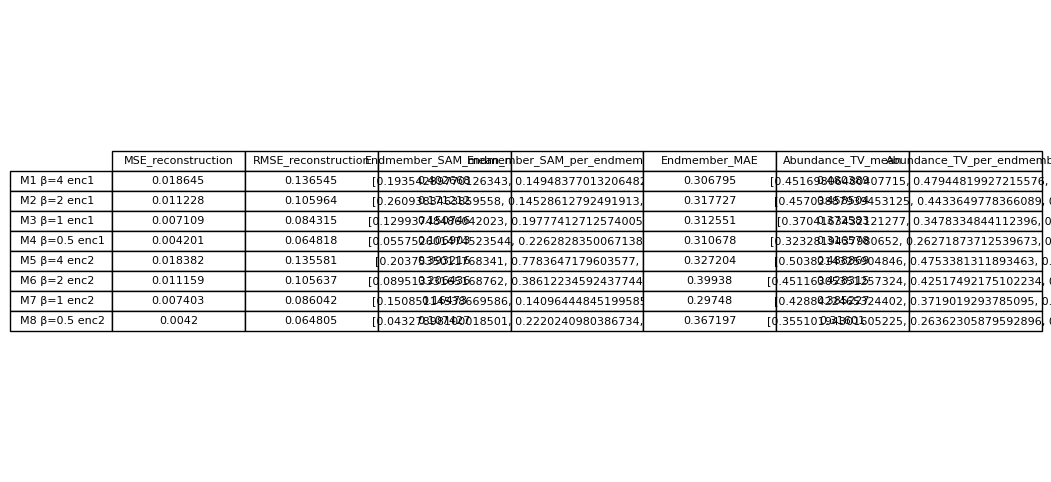

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

def compare_models(eval_results, model_names=None):
    """
    Crée un tableau comparatif des métriques de plusieurs modèles.
    
    Args:
        eval_results: liste de dictionnaires retournés par train_and_evaluate
        model_names: liste de noms de modèles (str), même longueur que eval_results
    """
    # si pas de noms fournis -> indices automatiques
    if model_names is None:
        model_names = [f"model_{i+1}" for i in range(len(eval_results))]

    # rassembler les dicts dans un DataFrame
    df = pd.DataFrame(eval_results, index=model_names)

    # afficher le tableau joliment
    print(df)

    # option : afficher avec matplotlib
    fig, ax = plt.subplots(figsize=(10, len(eval_results) * 0.5 + 2))
    ax.axis("off")
    table = ax.table(cellText=df.round(6).values,
                     rowLabels=df.index,
                     colLabels=df.columns,
                     loc="center",
                     cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.2, 1.2)
    plt.show()

    return df

evals = [eval_1, eval_2, eval_3, eval_4, eval_5, eval_6, eval_7, eval_8]
names = ["M1 β=4 enc1", "M2 β=2 enc1", "M3 β=1 enc1", "M4 β=0.5 enc1",
         "M5 β=4 enc2", "M6 β=2 enc2", "M7 β=1 enc2", "M8 β=0.5 enc2"]

df_results = compare_models(evals, names)



In [71]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_model_bars(eval_results, model_names=None, savepath=None):
    """
    Affiche des barplots comparant MSE (reconstruction), SAM (endmembers) et TV (abondances).

    Args:
        eval_results: liste de dicts retournés par train_and_evaluate(...)
        model_names:  liste de noms (même longueur que eval_results). Par défaut: ["model_1", ...]
        savepath:     chemin dossier pour sauvegarder les figures (facultatif). Si None, pas de save.
    """
    if model_names is None:
        model_names = [f"model_{i+1}" for i in range(len(eval_results))]

    # On collecte seulement les métriques utiles
    rows = []
    for res in eval_results:
        rows.append({
            "MSE_reconstruction": res.get("MSE_reconstruction", np.nan),
            "Endmember_SAM_mean_rad": res.get("Endmember_SAM_mean_rad", np.nan),
            "Abundance_TV_mean": res.get("Abundance_TV_mean", np.nan),
        })
    df = pd.DataFrame(rows, index=model_names)

    # Helper pour un barplot trié (plus petit = meilleur)
    def _barplot_sorted(series, title, ylabel, filename=None):
        # enlever tout-NaN
        s = series.dropna()
        if s.empty:
            print(f"[info] '{series.name}' indisponible (toutes valeurs NaN) → on saute ce plot.")
            return
        s = s.sort_values(ascending=True)

        plt.figure(figsize=(max(6, 0.75*len(s)+3), 4))
        bars = plt.bar(s.index, s.values)
        # labels au-dessus des barres
        for b, v in zip(bars, s.values):
            plt.text(b.get_x() + b.get_width()/2, b.get_height(),
                     f"{v:.4g}", ha='center', va='bottom', fontsize=9, rotation=0)
        plt.title(title + " (plus bas = mieux)")
        plt.ylabel(ylabel)
        plt.xticks(rotation=20, ha='right')
        plt.tight_layout()
        if savepath is not None and filename is not None:
            plt.savefig(f"{savepath.rstrip('/')}/{filename}", dpi=150)
        plt.show()

    # Tracés
    _barplot_sorted(df["MSE_reconstruction"], "MSE de reconstruction", "MSE", filename="bar_MSE.png")
    _barplot_sorted(df["Endmember_SAM_mean_rad"], "SAM moyen des endmembers (rad)", "SAM (rad)", filename="bar_SAM.png")
    _barplot_sorted(df["Abundance_TV_mean"], "TV moyenne des cartes d'abondance", "Total Variation", filename="bar_TV.png")

    return df  # pratique si tu veux aussi manipuler le tableau dans Python


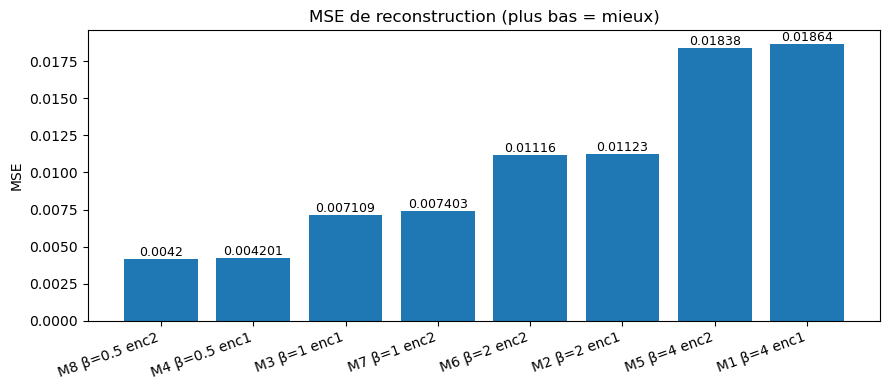

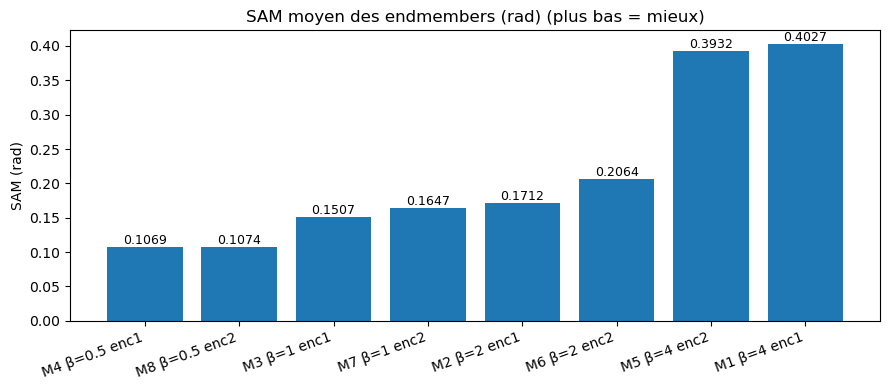

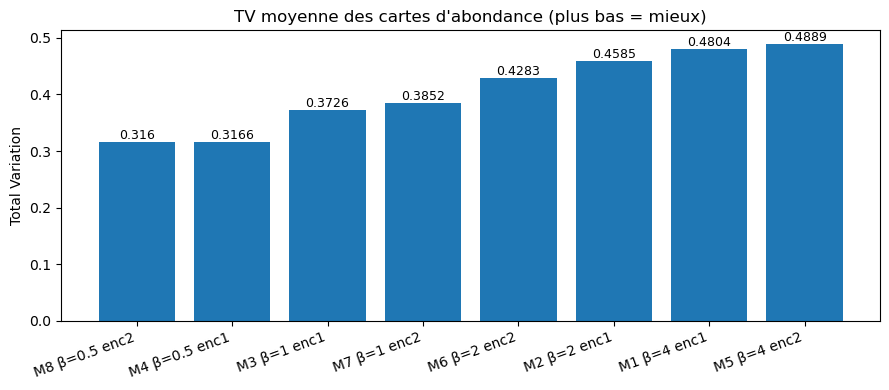

               MSE_reconstruction  Endmember_SAM_mean_rad  Abundance_TV_mean
M1 β=4 enc1              0.018645                0.402668           0.480389
M2 β=2 enc1              0.011228                0.171212           0.458504
M3 β=1 enc1              0.007109                0.150746           0.372583
M4 β=0.5 enc1            0.004201                0.106903           0.316578
M5 β=4 enc2              0.018382                0.393216           0.488869
M6 β=2 enc2              0.011159                0.206436           0.428315
M7 β=1 enc2              0.007403                0.164730           0.385227
M8 β=0.5 enc2            0.004200                0.107427           0.316010


In [72]:
evals = [eval_1, eval_2, eval_3, eval_4, eval_5, eval_6, eval_7, eval_8]
names = ["M1 β=4 enc1", "M2 β=2 enc1", "M3 β=1 enc1", "M4 β=0.5 enc1",
         "M5 β=4 enc2", "M6 β=2 enc2", "M7 β=1 enc2", "M8 β=0.5 enc2"]

df_table = plot_model_bars(evals, names)  # ou plot_model_bars(evals, names, savepath="./figs")
print(df_table.round(6))
